# 02. Classification Evaluation and Threshold

이진 분류 문제에서 평가 지표를 어떻게 읽어야 할까?
그리고 threshold를 어떻게 다뤄야 할까?

**목표**
1. accuracy 하나만으로 모델을 판단하면 왜 위험한지 확인한다.
2. confusion matrix, precision, recall, f1, ROC AUC, Average Precision의 의미를 연결해서 본다.
3. 확률 점수와 threshold의 관계를 이해한다.
4. validation 세트에서 threshold를 정하고, 마지막에만 test로 확인하는 흐름을 연습한다.

**주의할 점**
- 목적은 지표 암기가 아니라 판단 흐름 이해이다.
- 특히 threshold 0.5는 기본값일 뿐, 항상 정답은 아니다.
- 프로젝트에서는 비즈니스 목적에 따라 precision 우선, recall 우선, F1 우선 판단이 달라질 수 있다.

## 1. 왜 평가 지표와 threshold를 따로 봐야 하는가

분류 문제를 처음 다룰 때는 종종 아래처럼 접근하게 된다.

- accuracy가 높으면 좋은 모델이다.
- predict 결과가 나오면 끝이다.
- 0.5보다 크면 1, 아니면 0으로 두면 된다.

하지만 실제로는 이 세 가지가 모두 충분하지 않을 수 있다.

예를 들어 positive class가 상대적으로 적은 데이터에서는 무조건 0으로 많이 예측해도 accuracy가 꽤 나올 수 있다.

또한 모델이 내놓는 것은 단순히 0/1 결과만이 아니라 1일 가능성이 어느 정도인가에 대한 점수인 경우가 많다.

즉, 분류 문제에서는 아래 두 가지를 분리해서 봐야 한다.

1. 모델이 샘플들을 얼마나 잘 구분하고 있는가
   - ROC AUC, Average Precision 같은 threshold 독립적 지표로 본다.
2. 실제 운영 시 어느 기준으로 1이라고 판정할 것인가
   - precision, recall, f1, confusion matrix는 threshold에 따라 달라진다.

## 2. 실습 데이터

`make_classification()`으로 생성한 tabular 이진 분류 데이터를 사용한다.

데이터는 다음 특성을 가지도록 만든다.

- sample 수가 아주 작지 않다.
- informative feature와 noise feature가 섞여 있다.
- class imbalance가 어느 정도 있다.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 3. 데이터 생성

이번 데이터는 약간의 불균형과 라벨 노이즈를 포함하도록 만든다.

- `weights`: 클래스 비율
- `flip_y`: 라벨 노이즈 비율
- `class_sep`: 클래스 분리 정도

즉, 완전히 깨끗한 데이터가 아니라 현실적인 어려움이 조금 섞인 분류 데이터라고 보면 된다.

In [2]:
# 이진 분류용 tabular 데이터 생성
X, y = make_classification(
    n_samples=12000,          # 전체 샘플 수
    n_features=30,            # 전체 feature 수
    n_informative=10,         # 실제로 도움이 되는 feature 수
    n_redundant=6,            # informative feature의 조합으로 만든 중복 feature 수
    n_repeated=0,             # 반복 feature 수
    n_classes=2,              # 이진 분류
    n_clusters_per_class=2,   # 클래스별 cluster 수
    weights=[0.72, 0.28],     # 약간의 클래스 불균형
    flip_y=0.04,              # 라벨 노이즈
    class_sep=0.9,            # 클래스 분리 정도
    random_state=SEED
)

feature_names = [f'feature_{i:02d}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print('shape:', df.shape)
df.head()

shape: (12000, 31)


,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,target
0,1.358374,3.584573,-2.052339,-7.418526,-0.478628,-1.349334,-0.061837,0.903008,0.750935,-0.049824,...,1.511704,1.868044,0.223830,-0.379774,0.235185,-0.141190,2.996946,1.016877,0.974877,1
1,-0.487225,-0.802246,-1.014614,6.265392,1.553449,8.012887,0.932700,-0.330280,0.282922,-0.769743,...,-2.329832,-1.789196,-0.832501,-1.234943,1.397668,-4.398092,2.816330,0.472998,0.419905,0
2,-1.516402,-0.722782,1.262809,3.514417,0.816030,8.781202,-0.821640,-0.735248,-0.419626,-1.903751,...,5.686515,-0.668419,-1.214557,-0.776406,1.452049,-1.808776,5.020084,1.709963,1.930681,0
3,0.145712,-1.512005,2.172018,-6.164856,-1.242872,-5.558634,2.309538,-1.351000,-1.088102,1.092160,...,-2.972386,3.300607,0.939678,-1.396699,1.444081,0.078407,-2.989301,-2.779589,5.837671,0
4,0.609857,0.126410,0.163365,2.323290,0.617478,-3.004455,-1.654487,0.285974,0.071870,-1.608190,...,-0.611299,0.675900,1.464791,1.403445,-1.049440,1.372657,-1.656709,-0.993124,-3.127535,1


target
0    0.710167
1    0.289833
Name: proportion, dtype: float64


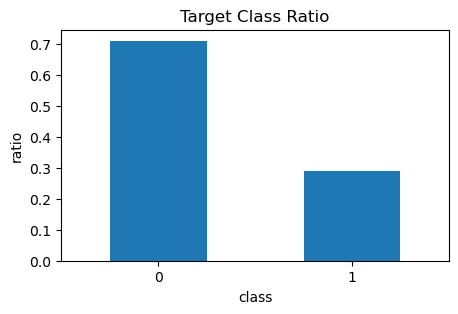

In [3]:
# 클래스 비율 확인
target_ratio = df['target'].value_counts(normalize=True).sort_index()
print(target_ratio)

plt.figure(figsize=(5, 3))
target_ratio.plot(kind='bar')
plt.title('Target Class Ratio')
plt.xlabel('class')
plt.ylabel('ratio')
plt.xticks(rotation=0)
plt.show()

## 4. train / validation / test 분리

- train: 모델 학습
- validation: 모델 비교, threshold 결정
- test: 마지막 1회 최종 확인

특히 threshold를 정할 때도 test를 보면 안 된다.

threshold까지 validation에서 정한 뒤, 마지막에 test에 딱 한 번 적용해야 한다.

In [4]:
# 먼저 train+validation 과 test로 분리
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

# train+validation에서 다시 train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 전체 기준으로는 0.2
    stratify=y_train_val,
    random_state=SEED
)

print('X_train shape:', X_train.shape)
print('X_val shape  :', X_val.shape)
print('X_test shape :', X_test.shape)

print()
print('train class ratio:', np.bincount(y_train) / len(y_train))
print('val class ratio  :', np.bincount(y_val) / len(y_val))
print('test class ratio :', np.bincount(y_test) / len(y_test))

X_train shape: (7200, 30)
X_val shape  : (2400, 30)
X_test shape : (2400, 30)

train class ratio: [0.71013889 0.28986111]
val class ratio  : [0.71041667 0.28958333]
test class ratio : [0.71 0.29]


## 5. 사용 모델

threshold 연습의 핵심은 확률 점수를 뽑아낼 수 있는 분류기를 기준으로 보는 것이다.

여기서는 아래 두 모델을 간단히 비교한다.

1. LogisticRegression
   - 선형 baseline
   - 확률 해석이 비교적 직관적이다.
2. HistGradientBoostingClassifier
   - 비선형 관계를 잘 잡을 수 있는 강한 baseline 후보이다.

어떤 모델이 1등인가 자체보다, 선택된 모델의 점수와 threshold를 어떻게 해석하는가이다.

In [5]:
def get_pred_and_score(model, X, threshold=0.5):
    '''
    모델에서 예측 라벨과 positive class 점수를 가져오는 함수이다.

    - score는 positive class(1)에 대한 점수이다.
    - predict_proba가 있으면 class 1 확률을 사용한다.
    - decision_function만 있으면 그 점수를 사용한다.
    - pred는 threshold를 기준으로 직접 만든다.
    '''
    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        raw_score = model.decision_function(X)

        # decision_function 값은 확률이 아니라 모델 내부 점수일 수 있다.
        # 따라서 ROC-AUC, AP처럼 순위 기반 지표에는 그대로 사용할 수 있지만,
        # threshold=0.5 같은 확률 기준을 바로 적용하는 것은 조심해야 한다.
        # 이런 점수를 확률처럼 해석하고 싶다면 calibration이 필요할 수 있다.
        score = raw_score
    else:
        raise ValueError('이 예제에서는 점수를 꺼낼 수 있는 분류기만 사용한다.')

    pred = (score >= threshold).astype(int)
    return pred, score


def evaluate_at_threshold(y_true, score, threshold=0.5):
    '''
    주어진 점수(score)와 threshold를 바탕으로
    threshold 의존 지표를 계산하는 함수이다.
    '''
    pred = (score >= threshold).astype(int)

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
    }


def evaluate_ranking_metrics(y_true, score):
    '''
    ROC AUC와 Average Precision은 threshold를 고정하기 전에
    모델이 positive 샘플을 얼마나 위로 잘 올리는지 보는 지표이다.
    '''
    return {
        'roc_auc': roc_auc_score(y_true, score),
        'average_precision': average_precision_score(y_true, score),
    }

In [6]:
# 모델 정의
models = {
    'logistic_regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=SEED))
    ]),
    'hist_gradient_boosting': HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.08,
        max_iter=250,
        random_state=SEED
    )
}

In [7]:
# train 데이터로 학습하고 validation에서 기본 threshold(0.5) 기준 성능과 ranking 지표를 본다.
val_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    _, val_score = get_pred_and_score(model, X_val, threshold=0.5)

    threshold_metrics = evaluate_at_threshold(y_val, val_score, threshold=0.5)
    ranking_metrics = evaluate_ranking_metrics(y_val, val_score)

    result = {'model': model_name}
    result.update(threshold_metrics)
    result.update(ranking_metrics)
    val_results.append(result)

val_df = pd.DataFrame(val_results)
val_df = val_df[['model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']]
val_df = val_df.sort_values(by='average_precision', ascending=False).reset_index(drop=True)

val_df

,model,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,hist_gradient_boosting,0.5,0.9275,0.939292,0.801439,0.864907,0.960074,0.932569
1,logistic_regression,0.5,0.8225,0.780793,0.538129,0.637138,0.847115,0.741477


## 6. 확인할 점

위 표에서는 두 종류의 지표가 섞여 있다.

1. threshold 의존 지표
- accuracy
- precision
- recall
- f1

2. threshold 독립적 지표
- roc_auc
- average_precision

즉, threshold를 아직 튜닝하지 않았더라도 ROC AUC와 Average Precision으로는 모델의 전반적인 분리 능력을 먼저 볼 수 있다.

반면 precision, recall, f1은 지금 우리가 임시로 `0.5`를 썼기 때문에 나온 숫자이다.

따라서 아래 질문을 던져야 한다.

- 모델이 원래부터 분리를 잘 못하는가
- 아니면 분리는 괜찮은데 threshold가 지금 목적과 안 맞는가

이 차이를 구분해야 잘못된 판단을 줄일 수 있다.

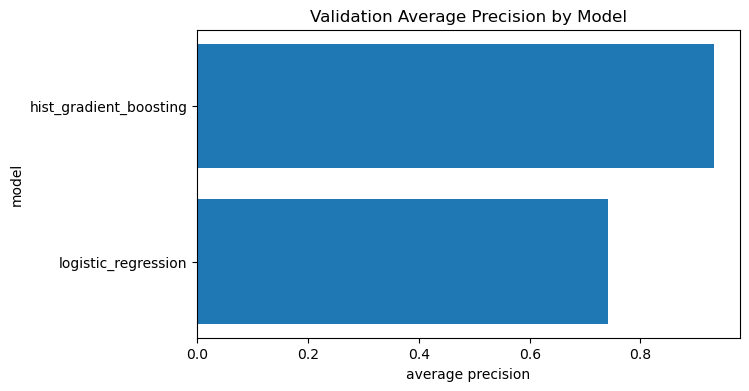

In [8]:
# validation average precision 비교 시각화
plt.figure(figsize=(7, 4))
plt.barh(val_df['model'], val_df['average_precision'])
plt.gca().invert_yaxis()
plt.title('Validation Average Precision by Model')
plt.xlabel('average precision')
plt.ylabel('model')
plt.show()

In [9]:
# threshold tuning 연습용으로 validation average precision이 더 높은 모델을 선택한다.
selected_model_name = val_df.iloc[0]['model']
selected_model = models[selected_model_name]

print('threshold tuning 대상 모델:', selected_model_name)

threshold tuning 대상 모델: hist_gradient_boosting


## 7. 기본 threshold 0.5에서 confusion matrix 보기

confusion matrix는 예측 결과를 네 칸으로 나누어 보여준다.

- TN: 실제 0, 예측 0
- FP: 실제 0, 예측 1
- FN: 실제 1, 예측 0
- TP: 실제 1, 예측 1

이 표가 중요한 이유는 precision, recall 같은 숫자가 결국 이 네 칸의 조합에서 나오기 때문이다.

즉, confusion matrix를 같이 봐야 지표의 의미가 더 잘 연결된다.

In [10]:
# 선택된 모델의 validation 점수와 예측 계산
val_pred_05, val_score = get_pred_and_score(selected_model, X_val, threshold=0.5)

cm_05 = confusion_matrix(y_val, val_pred_05)
print('selected model:', selected_model_name)
print('confusion matrix @ threshold=0.5')
print(cm_05)

print()
print('classification report @ threshold=0.5')
print(classification_report(y_val, val_pred_05, digits=4))

selected model: hist_gradient_boosting
confusion matrix @ threshold=0.5
[[1669   36]
 [ 138  557]]

classification report @ threshold=0.5
              precision    recall  f1-score   support

           0     0.9236    0.9789    0.9505      1705
           1     0.9393    0.8014    0.8649       695

    accuracy                         0.9275      2400
   macro avg     0.9315    0.8902    0.9077      2400
weighted avg     0.9282    0.9275    0.9257      2400



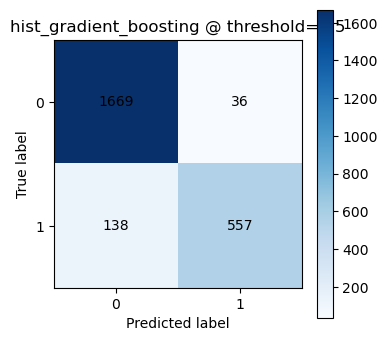

In [11]:
# confusion matrix를 heatmap 비슷하게 시각화하는 간단한 함수
def plot_confusion_matrix_simple(cm, title='Confusion Matrix'):
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks([0, 1], [0, 1])
    plt.yticks([0, 1], [0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.colorbar()
    plt.show()

plot_confusion_matrix_simple(cm_05, title=f'{selected_model_name} @ threshold=0.5')

## 8. threshold를 바꾸면 무엇이 달라지는가

보통 positive class로 판정하는 기준을 threshold라고 부른다.

예를 들어 score가 확률이라고 할 때,

- threshold = 0.5 이면 0.5 이상을 1로 본다.
- threshold = 0.3 이면 더 쉽게 1로 본다.
- threshold = 0.7 이면 더 엄격하게 1로 본다.

일반적으로는 다음 경향이 나타난다.

- threshold를 낮추면
  - positive를 더 많이 잡는다.
  - recall은 올라가기 쉽다.
  - 하지만 false positive도 늘어 precision이 떨어질 수 있다.
- threshold를 높이면
  - positive 판정을 더 보수적으로 한다.
  - precision은 올라갈 수 있다.
  - 하지만 실제 positive를 놓쳐 recall이 떨어질 수 있다.

즉,
threshold는 precision과 recall 사이의 균형을 움직이는 손잡이와 비슷하다.

In [12]:
# 여러 threshold에서 지표가 어떻게 바뀌는지 확인
threshold_grid = np.arange(0.10, 0.91, 0.05)

threshold_records = []
for th in threshold_grid:
    metrics = evaluate_at_threshold(y_val, val_score, threshold=th)
    threshold_records.append(metrics)

threshold_df = pd.DataFrame(threshold_records)
threshold_df.head()

,threshold,accuracy,precision,recall,f1
0,0.10,0.859583,0.689218,0.938129,0.794637
1,0.15,0.887083,0.748826,0.917986,0.824822
2,0.20,0.907500,0.802043,0.903597,0.849797
3,0.25,0.917083,0.834232,0.890647,0.861517
4,0.30,0.928333,0.874106,0.879137,0.876614


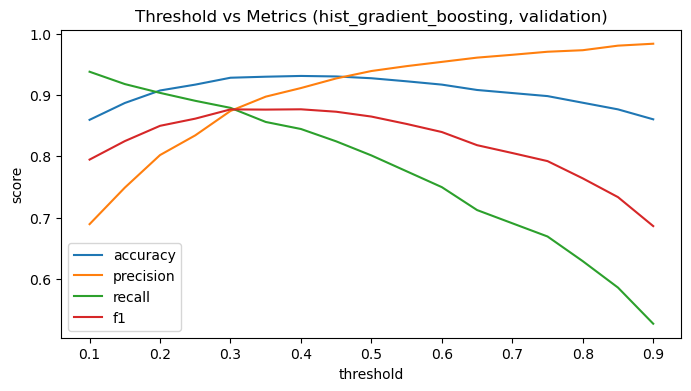

In [13]:
# threshold 변화에 따른 accuracy / precision / recall / f1 변화 시각화
plt.figure(figsize=(8, 4))
plt.plot(threshold_df['threshold'], threshold_df['accuracy'], label='accuracy')
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='f1')
plt.xlabel('threshold')
plt.ylabel('score')
plt.title(f'Threshold vs Metrics ({selected_model_name}, validation)')
plt.legend()
plt.show()

## 9. precision-recall curve와 ROC curve

threshold를 여러 개 바꿔가며 모델을 보면
곡선으로도 확인할 수 있다.

1. Precision-Recall Curve
- positive class를 얼마나 잘 끌어올리는지 볼 때 유용하다.
- 불균형 데이터에서는 특히 중요하게 보는 경우가 많다.

2. ROC Curve
- TPR과 FPR의 관계를 본다.
- 전체적인 분리 능력을 넓게 확인할 때 유용하다.

이번 예제에서는 class imbalance가 약간 있으므로
PR curve와 Average Precision을 특히 주의 깊게 본다.

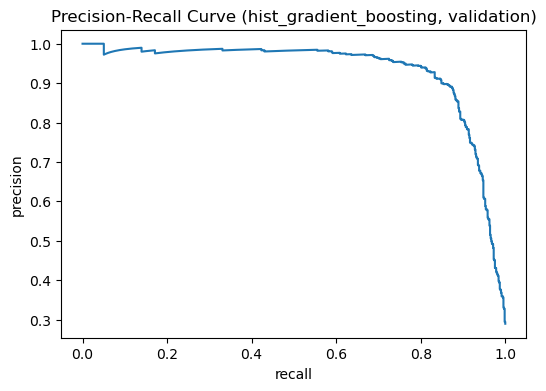

validation average precision: 0.9325694127576404


In [14]:
# PR curve 계산
precisions, recalls, pr_thresholds = precision_recall_curve(y_val, val_score)

plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions)
plt.xlabel('recall')
plt.ylabel('precision')
plt.title(f'Precision-Recall Curve ({selected_model_name}, validation)')
plt.show()

print('validation average precision:', average_precision_score(y_val, val_score))

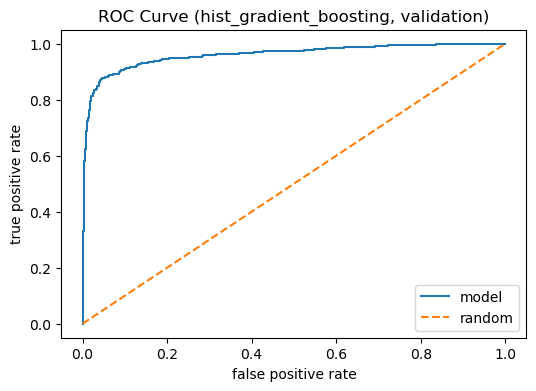

validation roc auc: 0.9600742631701089


In [15]:
# ROC curve 계산
fpr, tpr, roc_thresholds = roc_curve(y_val, val_score)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], linestyle='--', label='random')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title(f'ROC Curve ({selected_model_name}, validation)')
plt.legend()
plt.show()

print('validation roc auc:', roc_auc_score(y_val, val_score))

## 10. threshold 0.5가 항상 정답은 아니다

ROC AUC나 Average Precision이 높다고 해서
threshold 0.5에서 precision, recall, f1도 자동으로 가장 좋다는 뜻은 아니다.

왜냐하면
ROC AUC와 Average Precision은
점수의 순서와 분리 능력을 보는 지표이고,

precision, recall, f1은
어느 선에서 자를 것인가까지 포함한 결과이기 때문이다.

즉,
모델이 점수를 꽤 잘 만들고 있어도
threshold를 목적에 맞게 다시 잡아야 할 수 있다.

## 11. validation에서 threshold를 고르는 여러 방식

프로젝트에서는 threshold를 고르는 방법이 하나만 있는 것이 아니다.

예를 들어 다음과 같은 기준이 가능하다.

1. F1이 최대가 되는 threshold
- precision과 recall의 균형을 우선할 때

2. recall이 일정 수준 이상인 threshold 중 precision이 최대인 값
- 놓치면 안 되는 positive가 있을 때

3. precision이 일정 수준 이상인 threshold 중 recall이 최대인 값
- false positive가 너무 많으면 안 될 때

중요한 점은 목적을 먼저 정하고 threshold를 고른다는 것이다.

예시로 두 가지를 해본다.

- 전략 A: validation F1 최대
- 전략 B: validation recall이 0.80 이상인 후보 중 precision 최대

In [16]:
def find_best_threshold_by_f1(y_true, score, thresholds):
    best_row = None

    for th in thresholds:
        metrics = evaluate_at_threshold(y_true, score, threshold=th)

        if best_row is None or metrics['f1'] > best_row['f1']:
            best_row = metrics

    return best_row


def find_best_threshold_with_recall_constraint(y_true, score, thresholds, min_recall=0.80):
    candidates = []

    for th in thresholds:
        metrics = evaluate_at_threshold(y_true, score, threshold=th)

        if metrics['recall'] >= min_recall:
            candidates.append(metrics)

    if not candidates:
        return None

    # recall 조건을 만족하는 threshold들 중 precision이 가장 큰 것을 선택한다.
    # precision이 같으면 그 다음으로 f1이 큰 쪽을 선택한다.
    candidates = sorted(candidates, key=lambda x: (x['precision'], x['f1']), reverse=True)
    return candidates[0]

In [17]:
# threshold 후보를 조금 더 촘촘하게 만든다.
search_thresholds = np.arange(0.05, 0.96, 0.01)

best_f1_row = find_best_threshold_by_f1(y_val, val_score, search_thresholds)
best_recall_constraint_row = find_best_threshold_with_recall_constraint(
    y_val, val_score, search_thresholds, min_recall=0.80
)

print('전략 A: F1 최대 threshold')
print(best_f1_row)

print()
print('전략 B: recall >= 0.80 조건에서 precision 최대 threshold')
print(best_recall_constraint_row)

전략 A: F1 최대 threshold
{'threshold': 0.32000000000000006, 'accuracy': 0.9320833333333334, 'precision': 0.8888888888888888, 'recall': 0.874820143884892, 'f1': 0.8817984046410442}

전략 B: recall >= 0.80 조건에서 precision 최대 threshold
{'threshold': 0.5100000000000001, 'accuracy': 0.9283333333333333, 'precision': 0.9439728353140917, 'recall': 0.8, 'f1': 0.8660436137071651}


In [18]:
# 비교를 쉽게 보기 위해 기본 threshold와 함께 표로 정리
compare_rows = [
    evaluate_at_threshold(y_val, val_score, threshold=0.50),
    best_f1_row,
]

if best_recall_constraint_row is not None:
    compare_rows.append(best_recall_constraint_row)

compare_df = pd.DataFrame(compare_rows)
compare_df = compare_df.drop_duplicates(subset=['threshold']).sort_values(by='threshold').reset_index(drop=True)
compare_df

,threshold,accuracy,precision,recall,f1
0,0.32,0.932083,0.888889,0.874820,0.881798
1,0.50,0.927500,0.939292,0.801439,0.864907
2,0.51,0.928333,0.943973,0.800000,0.866044


## 12. threshold 전략별 confusion matrix 비교

confusion matrix도 같이 비교해보자.

같은 모델이라도 threshold가 달라지면

- false positive가 얼마나 늘었는지
- false negative가 얼마나 줄었는지

패턴이 달라진다.

이걸 실제로 보는 습관이 중요하다.

In [19]:
# 비교할 threshold 목록 만들기
threshold_candidates = [('default_0.50', 0.50)]

if best_f1_row is not None:
    threshold_candidates.append(('best_f1', float(best_f1_row['threshold'])))

if best_recall_constraint_row is not None:
    threshold_candidates.append(('recall_constraint', float(best_recall_constraint_row['threshold'])))

for label, th in threshold_candidates:
    pred = (val_score >= th).astype(int)
    cm = confusion_matrix(y_val, pred)

    print('=' * 60)
    print(f'{label} | threshold={th:.2f}')
    print(cm)
    print(classification_report(y_val, pred, digits=4))

default_0.50 | threshold=0.50
[[1669   36]
 [ 138  557]]
              precision    recall  f1-score   support

           0     0.9236    0.9789    0.9505      1705
           1     0.9393    0.8014    0.8649       695

    accuracy                         0.9275      2400
   macro avg     0.9315    0.8902    0.9077      2400
weighted avg     0.9282    0.9275    0.9257      2400

best_f1 | threshold=0.32
[[1629   76]
 [  87  608]]
              precision    recall  f1-score   support

           0     0.9493    0.9554    0.9524      1705
           1     0.8889    0.8748    0.8818       695

    accuracy                         0.9321      2400
   macro avg     0.9191    0.9151    0.9171      2400
weighted avg     0.9318    0.9321    0.9319      2400

recall_constraint | threshold=0.51
[[1672   33]
 [ 139  556]]
              precision    recall  f1-score   support

           0     0.9232    0.9806    0.9511      1705
           1     0.9440    0.8000    0.8660       695

    accurac

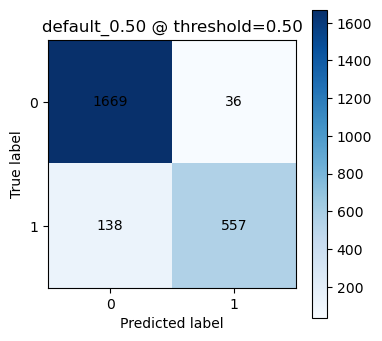

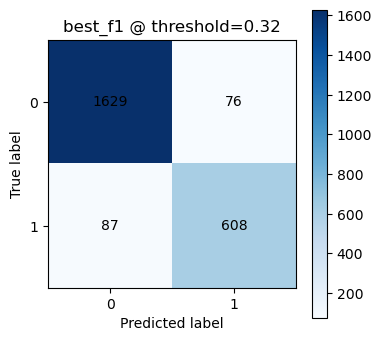

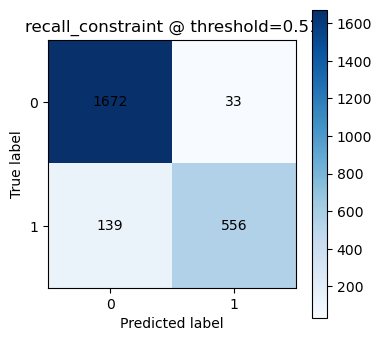

In [20]:
# confusion matrix를 나란히 확인
unique_threshold_candidates = []
seen = set()

for label, th in threshold_candidates:
    rounded = round(th, 4)
    if rounded not in seen:
        seen.add(rounded)
        unique_threshold_candidates.append((label, th))

for label, th in unique_threshold_candidates:
    pred = (val_score >= th).astype(int)
    cm = confusion_matrix(y_val, pred)
    plot_confusion_matrix_simple(cm, title=f'{label} @ threshold={th:.2f}')

## 13. 어떤 threshold를 선택할 것인가

정답은 하나가 아니다.

예를 들면,

- positive를 놓치면 안 되는 문제라면 recall 쪽을 더 본다.
- positive 판정을 잘못 내리면 비용이 큰 문제라면 precision 쪽을 더 본다.
- 둘 다 적당히 챙기고 싶다면 F1을 참고할 수 있다.

이 예제에서는
positive를 너무 많이 놓치지 않으면서도 precision을 챙기고 싶다는 가정을 두고
전략 B를 최종 threshold로 선택해보겠다.

단,
만약 프로젝트 목적이 다르면
다른 threshold를 선택할 수도 있다.

In [21]:
# 이번 예제의 최종 threshold 선택
# - 예시 가정: recall을 어느 정도 확보하면서 precision도 챙기고 싶다.
# - 따라서 recall >= 0.80 조건에서 precision이 가장 높은 threshold를 사용한다.
# - 만약 그런 threshold가 없으면 F1 최대 threshold를 대안으로 사용한다.
if best_recall_constraint_row is not None:
    final_threshold = float(best_recall_constraint_row['threshold'])
    threshold_strategy = 'recall>=0.80 중 precision 최대'
else:
    final_threshold = float(best_f1_row['threshold'])
    threshold_strategy = 'F1 최대 (대안 사용)'

print('최종 threshold 전략:', threshold_strategy)
print('최종 threshold:', final_threshold)

최종 threshold 전략: recall>=0.80 중 precision 최대
최종 threshold: 0.5100000000000001


## 14. test는 마지막에만

여기까지 threshold 선택은 전부 validation에서 했다.

이제야 비로소 선택된 threshold를 test에 적용한다.

중요한 점은 test 결과를 보고 다시 threshold를 바꾸면 안 된다는 것이다.

그렇게 되면 test가 최종 평가가 아니라 또 다른 튜닝용 validation처럼 변해버린다.

In [22]:
# test 점수 계산
_, test_score = get_pred_and_score(selected_model, X_test, threshold=0.5)

# ranking 지표는 threshold와 무관하게 계산
test_ranking_metrics = evaluate_ranking_metrics(y_test, test_score)

# 최종 threshold를 적용한 분류 지표 계산
test_threshold_metrics = evaluate_at_threshold(y_test, test_score, threshold=final_threshold)

test_result = {
    'selected_model': selected_model_name,
    'threshold_strategy': threshold_strategy,
    'final_threshold': final_threshold,
}
test_result.update(test_threshold_metrics)
test_result.update(test_ranking_metrics)

pd.DataFrame([test_result])

,selected_model,threshold_strategy,final_threshold,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,hist_gradient_boosting,recall>=0.80 중 precision 최대,0.51,0.51,0.908333,0.900673,0.768678,0.829457,0.943702,0.908048


selected model: hist_gradient_boosting
final threshold: 0.5100000000000001

confusion matrix on test
[[1645   59]
 [ 161  535]]

classification report on test
              precision    recall  f1-score   support

           0     0.9109    0.9654    0.9373      1704
           1     0.9007    0.7687    0.8295       696

    accuracy                         0.9083      2400
   macro avg     0.9058    0.8670    0.8834      2400
weighted avg     0.9079    0.9083    0.9060      2400



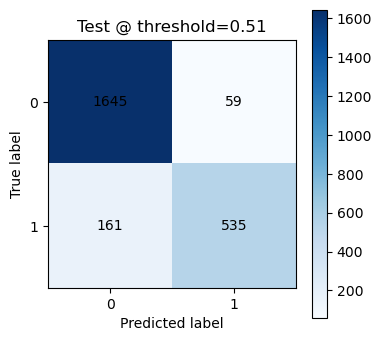

In [23]:
# 최종 threshold 기준 confusion matrix와 classification report
test_pred_final = (test_score >= final_threshold).astype(int)
test_cm = confusion_matrix(y_test, test_pred_final)

print('selected model:', selected_model_name)
print('final threshold:', final_threshold)
print()
print('confusion matrix on test')
print(test_cm)

print()
print('classification report on test')
print(classification_report(y_test, test_pred_final, digits=4))

plot_confusion_matrix_simple(test_cm, title=f'Test @ threshold={final_threshold:.2f}')

## 15. validation과 test를 함께 읽을 때 주의할 점

validation에서 잘 보이던 threshold가
test에서는 조금 덜 좋아 보일 수 있다.

왜냐하면 validation도 결국 표본이고,
threshold 선택 역시 validation 데이터의 특성을 반영하기 때문이다.

따라서 아래처럼 해석하는 편이 좋다.

- validation에서 threshold 방향을 정한다.
- test에서는 그 선택이 대체로 유지되는지 본다.
- 약간의 차이는 자연스러울 수 있다.
- 큰 차이가 난다면 데이터 분할, 과적합, 데이터 드리프트 가능성을 의심한다.

In [24]:
# validation과 test를 같은 threshold로 비교
final_val_metrics = evaluate_at_threshold(y_val, val_score, threshold=final_threshold)
final_test_metrics = evaluate_at_threshold(y_test, test_score, threshold=final_threshold)

summary_df = pd.DataFrame([
    {'split': 'validation', **final_val_metrics, **evaluate_ranking_metrics(y_val, val_score)},
    {'split': 'test', **final_test_metrics, **evaluate_ranking_metrics(y_test, test_score)},
])

summary_df

,split,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,validation,0.51,0.928333,0.943973,0.800000,0.866044,0.960074,0.932569
1,test,0.51,0.908333,0.900673,0.768678,0.829457,0.943702,0.908048


## 정리

1. accuracy 하나만으로 분류 모델을 판단하면 위험할 수 있다.
2. confusion matrix를 같이 봐야 precision, recall, f1의 의미가 선명해진다.
3. ROC AUC와 Average Precision은 threshold를 고정하기 전 분리 능력을 본다.
4. precision, recall, f1은 threshold에 따라 달라진다.
5. threshold 0.5는 기본값일 뿐, 항상 최선은 아니다.
6. threshold는 validation에서 비즈니스 목적에 맞게 정해야 한다.
7. threshold까지 정한 뒤 마지막에만 test를 봐야 한다.

즉, 모델 점수와 운영 기준값(threshold)을 구분해서 생각하는 것이다.